In [1]:
import copy
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from cadft.utils import Grid
from cadft import CC_DFT_DATA, Mol


fontsize = 10.045
sca_size = 2
plt.rc("font", size=fontsize)  # controls default text size
plt.rc("axes", titlesize=fontsize)  # fontsize of the title
plt.rc("axes", labelsize=fontsize - 1)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=fontsize - 2)  # fontsize of the x tick labels
plt.rc("ytick", labelsize=fontsize - 2)  # fontsize of the y tick labels
plt.rc("legend", fontsize=fontsize)  # fontsize of the legend

plt.rcParams["figure.figsize"] = np.array([0.95, 0.5]) * 520 / 72

rcParams["axes.linewidth"] = 1.5
rcParams["lines.linewidth"] = 1.5
rcParams["xtick.major.width"] = 3
rcParams["xtick.minor.size"] = 5
rcParams["xtick.major.size"] = 5
rcParams["ytick.minor.size"] = 5
rcParams["ytick.major.size"] = 5
rcParams["xtick.minor.width"] = 1.5
rcParams["xtick.major.width"] = 1.5
rcParams["ytick.minor.width"] = 1.5
rcParams["ytick.major.width"] = 1.5

# mol_list = ["methyl-openshell"]
# mol_list = ["propylene"]
mol_list = ["acetylene"]
# data_propylene_cc - pCVTZ_0 - 1_1_0.2000
distance_list = [0.2]

ang_to_au = 1 / 0.52917721067

MAIN_PATH: /home/chenzihao/workspace/cadft
DATA_PATH: /home/chenzihao/workspace/cadft/data/grids_mrks
DATA_SAVE_PATH: /home/chenzihao/workspace/cadft/data/grids_mrks/saved_data
DATA_CC_PATH: /home/chenzihao/workspace/cadft/data/test


Rotate the molecular to certain direction
before rotation [['C', -0.39999999999999997, 0, 0], ['C', 0.6, 0, 0], ['H', -1.665, 0, -0.0001], ['H', 1.665, 0, 0.0001]]
after rotation [['C', 0.49225787698908574, 1.4227997063678128e-05, 0.0], ['C', -0.5077421225932067, -1.4675546633298504e-05, 0.0], ['H', 1.7572578793510403, -4.9209020117875684e-05, 0.0], ['H', -1.5727421250387028, 5.454217928765064e-05, 0.0]]
System: uname_result(system='Linux', node='dgxa100svr02', release='5.4.0-200-generic', version='#220-Ubuntu SMP Fri Sep 27 13:19:16 UTC 2024', machine='x86_64')  Threads 48
Python 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:27:36) [GCC 11.2.0]
numpy 1.26.4  scipy 1.14.1  h5py 3.12.1
Date: Thu Dec  5 19:58:41 2024
PySCF version 2.7.0
PySCF path  /home/chenzihao/anaconda3/envs/pyscf/lib/python3.12/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 4
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 

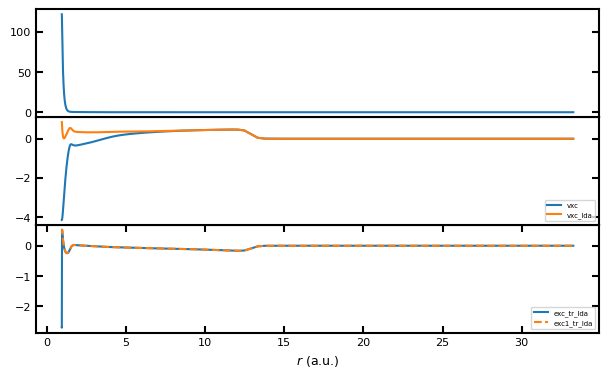

<Figure size 686.111x361.111 with 0 Axes>

In [15]:
for mol, distance in product(mol_list, distance_list):
    molecular = copy.deepcopy(Mol[mol])
    molecular[0][1] += distance

    dft2cc = CC_DFT_DATA(
        molecular,
        name="test",
        basis="STO-3G",
        if_basis_str=True,
        # spin=1,
    )

    grids = Grid(dft2cc.mol)
    coords = grids.coords

    data_path = (
        "/home/chenzihao/raid/data/grids_mrks_ccsd_1/data_methane_cc-pVDZ_0-1_1_-0.5000.npz"
    )

    # print create time of data_path

    data = np.load(data_path)
    # data = np.load(
    #     "../data/grids_mrks_CVTZ_1/data/data_methane_cc-pCVTZ_0_1_-0.5000_bk.npz"
    # )

    input_mat = data["rho_inv_4_norm"]
    middle_mat = data["vxc1_lda"]
    output_mat = data["exc1_tr_lda"]
    for i_atom in range(dft2cc.mol.natm):
        input_ = input_mat[[0], i_atom, :, :]
        middle_ = middle_mat[[i_atom], :, :]
        output_ = output_mat[[i_atom], :, :]
        print(
            f"mean input: {np.mean(input_):>7.4e}, "
            f"max input: {np.max(np.abs(input_)):>7.4e}, "
            f"var input: {np.var(input_):>7.4e}\n"
            f"mean middle: {np.mean(middle_):>7.4e}, "
            f"max middle: {np.max(np.abs(middle_)):>7.4e}, "
            f"var middle: {np.var(middle_):>7.4e}\n"
            f"mean output: {np.mean(output_):>7.4e}, "
            f"max output: {np.max(np.abs(output_)):>7.4e} "
            f"var output: {np.var(output_):>7.4e}\n"
        )
    rho_inv = data["rho_inv_4_norm"][0, :]
    # rho_inv_4 = data["rho_inv_4"]
    weights_grids = data["weights"]
    print("number of ele", np.sum(rho_inv * weights_grids))

    x = grids.vector_to_matrix(coords[:, 0])
    y = grids.vector_to_matrix(coords[:, 1])
    z = grids.vector_to_matrix(coords[:, 2])

    index_ = np.index_exp[0, :, 0]
    r_vec = np.sqrt(x[index_] ** 2 + y[index_] ** 2 + z[index_] ** 2)
    # x = x[index_]

    f, axes = plt.subplots(3, 1)
    axes = axes.reshape(3, 1)

    begin_y = 0.1
    end_y = 0.995
    int_y = 0.0
    begin_x = 0.175
    end_x = 0.995
    int_x = 0.0
    end_x += int_x
    end_y += int_y

    shapexy = np.shape(axes)
    inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
    inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

    delta_x = inter_x[1] - inter_x[0] - int_x
    delta_y = inter_y[1] - inter_y[0] - int_y

    for i in range(shapexy[0]):
        for j in range(shapexy[1]):
            axes[i][j].set_position(
                [
                    inter_x[j],
                    inter_y[i],
                    inter_x[j + 1] - inter_x[j] - int_x,
                    inter_y[i + 1] - inter_y[i] - int_y,
                ]
            )
            axes[i][j].xaxis.set_tick_params(
                direction="in", which="both", bottom=True, top=True
            )
            axes[i][j].yaxis.set_tick_params(
                direction="in", which="both", left=True, right=True
            )

    axes = axes[::-1, :]

    y11 = data["exc_tr_lda"][index_]
    y12 = data["exc1_tr_lda"][index_]
    y21 = data["vxc"][index_]
    y22 = data["vxc1_lda"][index_]
    y31 = data["rho_inv_4_norm"][0, :][index_]

    axes[0, 0].plot(r_vec, y31)
    axes[1, 0].plot(r_vec, y21, label="vxc")
    axes[1, 0].plot(r_vec, y22, label="vxc_lda")
    axes[2, 0].plot(r_vec, y11, label="exc_tr_lda")
    axes[2, 0].plot(r_vec, y12, "--", label="exc1_tr_lda")

    # axes[0, 0].set_xlim(-0.5, 0.5)
    # axes[1, 0].set_xlim(-0.5, 0.5)
    # axes[2, 0].set_xlim(-0.5, 0.5)

    # axes[0, 0].set_ylabel(r"$\rho_{\textrm{input}}(\bm{\mathrm{r}})$ (a.u.)")
    # axes[1, 0].set_ylabel(r"$v_{\textrm{target}}(\bm{\mathrm{r}})$ (a.u.)")
    # axes[2, 0].set_ylabel(r"$E_{\textrm{target}}(\bm{\mathrm{r}})$ (a.u.)")

    axes[0, 0].set_xticks([])
    axes[1, 0].set_xticks([])
    axes[2, 0].set_xlabel(r"$r$ (a.u.)")

    print(len(x))
    # plt.savefig(f"../manu/figures/{mol}_cc-pCVTZ_0_1_{distance:.4f}.pdf")
    axes[1, 0].legend(loc="best", fontsize=fontsize // 2)
    axes[2, 0].legend(loc="best", fontsize=fontsize // 2)

    # axes[0, 0].set_ylim(-1e-1, 1e-1)
    # axes[2, 0].set_ylim(-1e-1, 1e-1)
    # for i in range(shapexy[0]):
    #     for j in range(shapexy[1]):
    #         axes[i][j].set_xlim(-1.5, 1.5)
    plt.show()
    plt.clf()

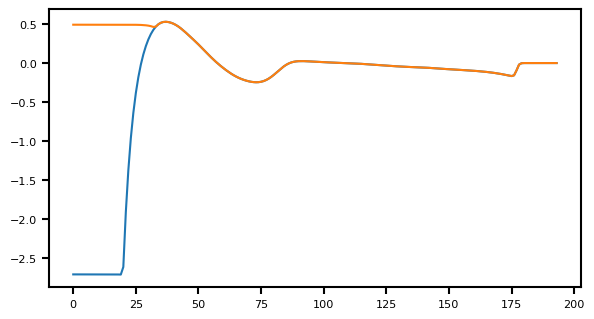

In [17]:
plt.plot(y11, label="exc_tr_lda")
plt.plot(y12, label="exc_tr_lda")

2560


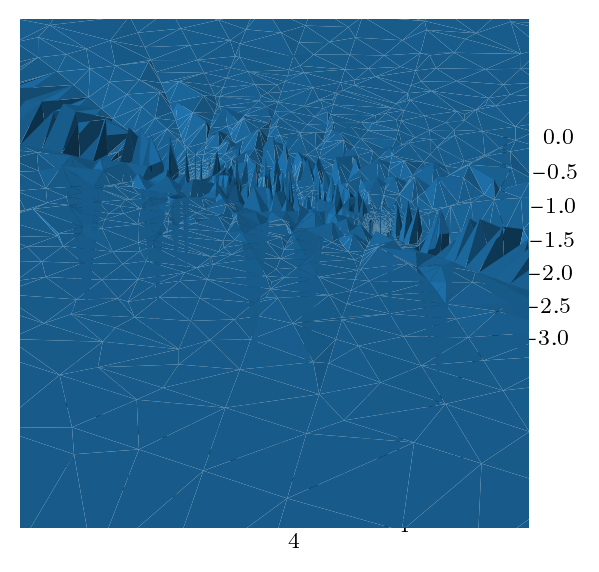

In [4]:
index_ = np.where((np.abs(coords[:, 2]) < 1e-10))
sort_ = np.argsort(coords[:, 0][index_])
x = coords[:, 0][index_][sort_]
y = coords[:, 1][index_][sort_]
# z11 = (grids.matrix_to_vector(exc))[index_][sort_]
z12 = (grids.matrix_to_vector(exc_real))[index_][sort_]
# z2 = (grids.matrix_to_vector(vxc))[index_][sort_]

fig = plt.figure(figsize=plt.figaspect(0.5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
# ax.plot_trisurf(x, y, z11, label="exc")
ax.plot_trisurf(x, y, z12, label="exc_real")
# ax.plot_trisurf(x, y, z2, label="vxc")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
# ax.set_zlim(-5, 5)
# plt.xlim(1.13, 1.155)

# plt.legend(loc='upper right')
print(len(x))

In [4]:
365 - 2 * 54 - 17 - 22, 2 * 54 + 17 + 22

(218, 147)

In [ ]:
import torch

torch.cuda.mem_get_info()[0] // 8 // 140**4

In [ ]:
for hash_char in ["0", "1"]:
    print("1_1".startswith(f"{hash_char}_"))

In [ ]:
x = np.linspace(-10, 10, 1000)
# plt.plot(x, 1 / (1 + np.exp(-100 * (x-1))))
plt.plot(x, 1/ (1 + np.exp(100 * (x-5))))

In [ ]:
1.732 / 2